# **EE 413: Applied Digital Signal Processing**

##*Project: Image Compression and Classification with Deep Learning*

**Dataset:** *Mini-ImageNet*


**Application of course topics:**

Topic 1:  Wavelet Transform

Topic 2: Convex Optimization

Topic 3: Compressed Sensing

##**Team Members:**

- Ahmad Edrees Al-Eid - 20215490 | Model Selection and Fine-tuning (Baseline Establishment)
- Mohammed Aldubais - 202223380 | Wavelet-based Image Compression
- Ali Alhajji - 202264620 | Fine-tuning on Compressed Data - Model 1
- Faisal Alsalhi - 202168610 | Fine-tuning on Compressed Data - Model 2

## 1. Model Selection and Baseline Establishment

### Tools and Libraries

In [1]:
import os
from google.colab import drive
import tarfile
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pywt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

seed_orbit = 413
random.seed(seed_orbit)
np.random.seed(seed_orbit)
torch.manual_seed(seed_orbit)
torch.cuda.manual_seed_all(seed_orbit)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

run_device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", run_device)

device: cuda


### Load and extract the dataset

In [2]:
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/EE413/miniimagenet'

train_tar_path = base_path + '/train.tar'
test_tar_path  = base_path + '/test.tar'
val_tar_path   = base_path + '/val.tar'
extract_path = '/content/miniimagenet'
os.makedirs(extract_path, exist_ok=True)


if not os.path.exists('/content/miniimagenet/train'):
    with tarfile.open(train_tar_path, 'r') as tar:
        tar.extractall(extract_path)

if not os.path.exists('/content/miniimagenet/test'):
    with tarfile.open(test_tar_path, 'r') as tar:
        tar.extractall(extract_path)

if not os.path.exists('/content/miniimagenet/val'):
    with tarfile.open(val_tar_path, 'r') as tar:
        tar.extractall(extract_path)

train_dir = '/content/miniimagenet/train'
test_dir  = '/content/miniimagenet/test'
val_dir   = '/content/miniimagenet/val'

Mounted at /content/drive


/tmp/ipykernel_5093/551556795.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
/tmp/ipykernel_5093/551556795.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
/tmp/ipykernel_5093/551556795.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


In [3]:
img_size = 96
batch_size = 64
val_frac = 0.10
test_frac = 0.10
num_staff = 2

tfm_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

tfm_eval = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

ds_train_aug = datasets.ImageFolder(train_dir, transform=tfm_train)
ds_train_eval = datasets.ImageFolder(train_dir, transform=tfm_eval)

all_idx = list(range(len(ds_train_aug)))
all_targets = ds_train_aug.targets

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=(val_frac + test_frac),
    stratify=all_targets,
    random_state=seed_orbit
)

temp_targets = [all_targets[i] for i in temp_idx]
valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(test_frac / (val_frac + test_frac)),
    stratify=temp_targets,
    random_state=seed_orbit
)

set_train = Subset(ds_train_aug, train_idx)
set_valid = Subset(ds_train_eval, valid_idx)
set_test = Subset(ds_train_eval, test_idx)
ldr_train = DataLoader(set_train, batch_size=batch_size, shuffle=True,  num_workers=num_staff, pin_memory=True)
ldr_valid = DataLoader(set_valid, batch_size=batch_size, shuffle=False, num_workers=num_staff, pin_memory=True)
ldr_test = DataLoader(set_test,   batch_size=batch_size, shuffle=False, num_workers=num_staff, pin_memory=True)
class_galaxy = ds_train_aug.classes
n_classes = len(class_galaxy)
print(f"#train={len(set_train)} | #val={len(set_valid)} | #test={len(set_test)} | #classes={n_classes}")
print("first 5 classes:", class_galaxy[:5])

#train=30720 | #val=3840 | #test=3840 | #classes=64
first 5 classes: ['n01532829', 'n01558993', 'n01704323', 'n01749939', 'n01770081']


### My training settings

In [4]:
epoch_budget = 8
lr_res = 0.0003
lr_mob = 0.0004
wd_common = 0.0001
stop_patience = 3
loss_oracle = nn.CrossEntropyLoss()

ResNet-18 Model

In [5]:
resnet_star = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
res_in = resnet_star.fc.in_features
resnet_star.fc = nn.Linear(res_in, n_classes)
resnet_star = resnet_star.to(run_device)

opt_res = optim.AdamW(resnet_star.parameters(), lr=lr_res, weight_decay=wd_common)
sch_res = optim.lr_scheduler.ReduceLROnPlateau(opt_res, mode='max', factor=0.5, patience=1)

print(resnet_star.fc)
print("ResNet18 trainable params:", sum(p.numel() for p in resnet_star.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


Linear(in_features=512, out_features=64, bias=True)
ResNet18 trainable params: 11209344


In [6]:
res_history = []
best_res_val = 0.0
best_res_state = None
res_patience_counter = 0

for ep in range(1, epoch_budget + 1):
    resnet_star.train()
    ep_train_loss = 0.0
    ep_train_correct = 0
    ep_train_total = 0

    for xb, yb in ldr_train:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        opt_res.zero_grad()
        logits = resnet_star(xb)
        loss = loss_oracle(logits, yb)
        loss.backward()
        opt_res.step()

        ep_train_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        ep_train_correct += (pred == yb).sum().item()
        ep_train_total += yb.size(0)

    train_loss_epoch = ep_train_loss / ep_train_total
    train_acc_epoch = ep_train_correct / ep_train_total

    resnet_star.eval()
    ep_val_loss = 0.0
    ep_val_correct = 0
    ep_val_total = 0

    with torch.no_grad():
        for xb, yb in ldr_valid:
            xb = xb.to(run_device, non_blocking=True)
            yb = yb.to(run_device, non_blocking=True)

            logits = resnet_star(xb)
            loss = loss_oracle(logits, yb)

            ep_val_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            ep_val_correct += (pred == yb).sum().item()
            ep_val_total += yb.size(0)

    val_loss_epoch = ep_val_loss / ep_val_total
    val_acc_epoch = ep_val_correct / ep_val_total

    sch_res.step(val_acc_epoch)

    row = {
        "epoch": ep,
        "train_loss": train_loss_epoch,
        "train_acc": train_acc_epoch,
        "val_loss": val_loss_epoch,
        "val_acc": val_acc_epoch,
        "lr_now": opt_res.param_groups[0]["lr"]
    }
    res_history.append(row)

    if val_acc_epoch > best_res_val:
        best_res_val = val_acc_epoch
        best_res_state = {k: v.detach().cpu().clone() for k, v in resnet_star.state_dict().items()}
        res_patience_counter = 0
    else:
        res_patience_counter += 1
        if res_patience_counter >= stop_patience:
            break

if best_res_state is not None:
    resnet_star.load_state_dict(best_res_state)

res_hist_df = pd.DataFrame(res_history)
display(res_hist_df)

,epoch,train_loss,train_acc,val_loss,val_acc,lr_now
0,1,1.527763,0.592578,1.215194,0.661719,0.000300
1,2,0.955773,0.726823,1.104344,0.696094,0.000300
2,3,0.739288,0.785514,1.076106,0.711458,0.000300
3,4,0.595359,0.822363,1.133063,0.696615,0.000300
4,5,0.485097,0.854297,1.166305,0.700781,0.000150
5,6,0.250801,0.926660,0.991258,0.755990,0.000150
6,7,0.151526,0.956836,1.035419,0.753125,0.000150
7,8,0.115868,0.967969,1.079051,0.748437,0.000075


In [7]:
resnet_star.eval()
res_pred = []
res_true = []
res_test_loss_sum = 0.0
res_test_total = 0

with torch.no_grad():
    for xb, yb in ldr_test:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        logits = resnet_star(xb)
        loss = loss_oracle(logits, yb)

        res_test_loss_sum += loss.item() * xb.size(0)
        res_test_total += yb.size(0)

        pred = logits.argmax(dim=1)
        res_pred.extend(pred.cpu().numpy().tolist())
        res_true.extend(yb.cpu().numpy().tolist())

res_test_loss = res_test_loss_sum / res_test_total
res_test_acc = accuracy_score(res_true, res_pred)
res_test_f1m = f1_score(res_true, res_pred, average="macro")

print("ResNet18 test_loss:", round(res_test_loss, 4))
print("ResNet18 test_acc :", round(res_test_acc, 4))
print("ResNet18 macro_f1 :", round(res_test_f1m, 4))
print(classification_report(res_true, res_pred, target_names=class_galaxy, digits=3))

ResNet18 test_loss: 0.9869
ResNet18 test_acc : 0.7471
ResNet18 macro_f1 : 0.7473
              precision    recall  f1-score   support

   n01532829      0.822     0.617     0.705        60
   n01558993      0.793     0.767     0.780        60
   n01704323      0.887     0.783     0.832        60
   n01749939      0.815     0.883     0.848        60
   n01770081      0.808     0.700     0.750        60
   n01843383      0.887     0.917     0.902        60
   n01910747      0.867     0.867     0.867        60
   n02074367      0.864     0.850     0.857        60
   n02089867      0.750     0.700     0.724        60
   n02091831      0.649     0.833     0.730        60
   n02101006      0.692     0.750     0.720        60
   n02105505      0.852     0.867     0.860        60
   n02108089      0.629     0.650     0.639        60
   n02108551      0.776     0.750     0.763        60
   n02108915      0.647     0.550     0.595        60
   n02111277      0.692     0.750     0.720        60


MobileNetV3 Model

In [8]:
mobile_pulse = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
mob_in = mobile_pulse.classifier[-1].in_features
mobile_pulse.classifier[-1] = nn.Linear(mob_in, n_classes)
mobile_pulse = mobile_pulse.to(run_device)

opt_mob = optim.AdamW(mobile_pulse.parameters(), lr=lr_mob, weight_decay=wd_common)
sch_mob = optim.lr_scheduler.ReduceLROnPlateau(opt_mob, mode='max', factor=0.5, patience=1)

print(mobile_pulse.classifier)
print("MobileNetV3-Small trainable params:", sum(p.numel() for p in mobile_pulse.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 195MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=64, bias=True)
)
MobileNetV3-Small trainable params: 1583456


In [9]:
mob_history = []
best_mob_val = 0.0
best_mob_state = None
mob_patience_counter = 0

for ep in range(1, epoch_budget + 1):
    mobile_pulse.train()
    ep_train_loss = 0.0
    ep_train_correct = 0
    ep_train_total = 0

    for xb, yb in ldr_train:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        opt_mob.zero_grad()
        logits = mobile_pulse(xb)
        loss = loss_oracle(logits, yb)
        loss.backward()
        opt_mob.step()

        ep_train_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        ep_train_correct += (pred == yb).sum().item()
        ep_train_total += yb.size(0)

    train_loss_epoch = ep_train_loss / ep_train_total
    train_acc_epoch = ep_train_correct / ep_train_total

    mobile_pulse.eval()
    ep_val_loss = 0.0
    ep_val_correct = 0
    ep_val_total = 0

    with torch.no_grad():
        for xb, yb in ldr_valid:
            xb = xb.to(run_device, non_blocking=True)
            yb = yb.to(run_device, non_blocking=True)

            logits = mobile_pulse(xb)
            loss = loss_oracle(logits, yb)

            ep_val_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            ep_val_correct += (pred == yb).sum().item()
            ep_val_total += yb.size(0)

    val_loss_epoch = ep_val_loss / ep_val_total
    val_acc_epoch = ep_val_correct / ep_val_total

    sch_mob.step(val_acc_epoch)

    row = {
        "epoch": ep,
        "train_loss": train_loss_epoch,
        "train_acc": train_acc_epoch,
        "val_loss": val_loss_epoch,
        "val_acc": val_acc_epoch,
        "lr_now": opt_mob.param_groups[0]["lr"]
    }
    mob_history.append(row)

    if val_acc_epoch > best_mob_val:
        best_mob_val = val_acc_epoch
        best_mob_state = {k: v.detach().cpu().clone() for k, v in mobile_pulse.state_dict().items()}
        mob_patience_counter = 0
    else:
        mob_patience_counter += 1
        if mob_patience_counter >= stop_patience:
            break

if best_mob_state is not None:
    mobile_pulse.load_state_dict(best_mob_state)

mob_hist_df = pd.DataFrame(mob_history)
display(mob_hist_df)

,epoch,train_loss,train_acc,val_loss,val_acc,lr_now
0,1,1.853478,0.509212,1.209572,0.658854,0.0004
1,2,1.103099,0.689355,1.087735,0.702344,0.0004
2,3,0.894339,0.741374,1.094274,0.695052,0.0004
3,4,0.750636,0.778613,1.066837,0.708333,0.0004
4,5,0.633417,0.809375,1.083027,0.713281,0.0004
5,6,0.543075,0.835221,1.126307,0.709375,0.0004
6,7,0.475108,0.853581,1.160015,0.707292,0.0002
7,8,0.316292,0.902637,1.115754,0.725000,0.0002


In [10]:
mobile_pulse.eval()
mob_pred = []
mob_true = []
mob_test_loss_sum = 0.0
mob_test_total = 0

with torch.no_grad():
    for xb, yb in ldr_test:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        logits = mobile_pulse(xb)
        loss = loss_oracle(logits, yb)

        mob_test_loss_sum += loss.item() * xb.size(0)
        mob_test_total += yb.size(0)

        pred = logits.argmax(dim=1)
        mob_pred.extend(pred.cpu().numpy().tolist())
        mob_true.extend(yb.cpu().numpy().tolist())

mob_test_loss = mob_test_loss_sum / mob_test_total
mob_test_acc = accuracy_score(mob_true, mob_pred)
mob_test_f1m = f1_score(mob_true, mob_pred, average="macro")

print("MobileNetV3-Small test_loss:", round(mob_test_loss, 4))
print("MobileNetV3-Small test_acc :", round(mob_test_acc, 4))
print("MobileNetV3-Small macro_f1 :", round(mob_test_f1m, 4))
print(classification_report(mob_true, mob_pred, target_names=class_galaxy, digits=3))

MobileNetV3-Small test_loss: 1.1171
MobileNetV3-Small test_acc : 0.726
MobileNetV3-Small macro_f1 : 0.7254
              precision    recall  f1-score   support

   n01532829      0.754     0.717     0.735        60
   n01558993      0.860     0.717     0.782        60
   n01704323      0.880     0.733     0.800        60
   n01749939      0.771     0.900     0.831        60
   n01770081      0.814     0.800     0.807        60
   n01843383      0.898     0.883     0.891        60
   n01910747      0.791     0.883     0.835        60
   n02074367      0.839     0.783     0.810        60
   n02089867      0.705     0.717     0.711        60
   n02091831      0.592     0.700     0.641        60
   n02101006      0.690     0.667     0.678        60
   n02105505      0.823     0.850     0.836        60
   n02108089      0.623     0.550     0.584        60
   n02108551      0.712     0.700     0.706        60
   n02108915      0.566     0.500     0.531        60
   n02111277      0.582     

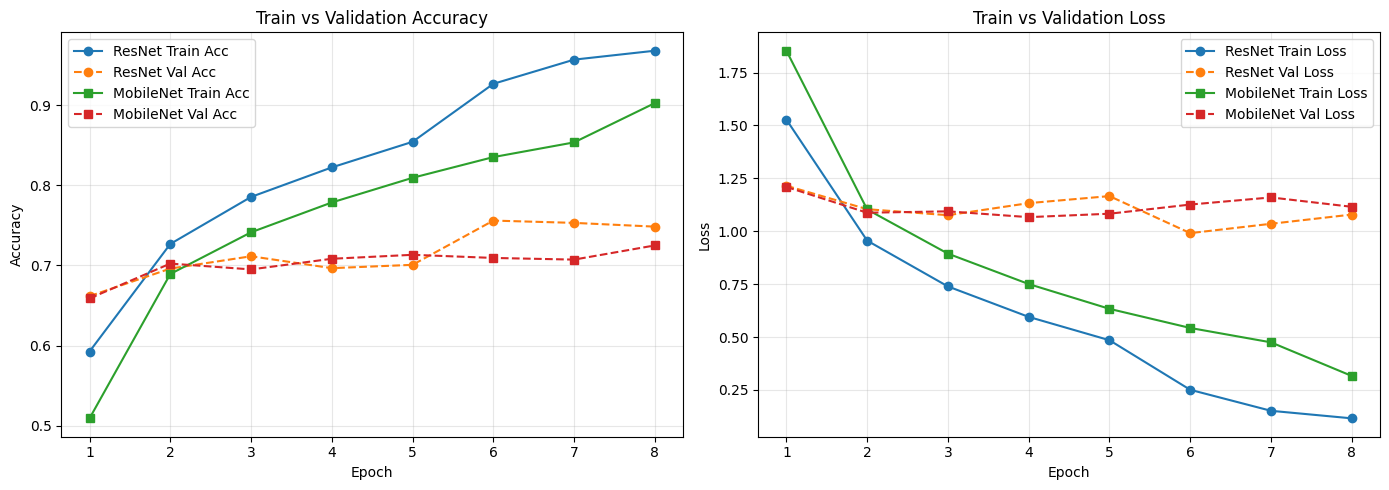

In [11]:
res_df = pd.DataFrame(res_history)
mob_df = pd.DataFrame(mob_history)

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(res_df["epoch"], res_df["train_acc"], marker='o', label="ResNet Train Acc")
plt.plot(res_df["epoch"], res_df["val_acc"], marker='o', linestyle='--', label="ResNet Val Acc")
plt.plot(mob_df["epoch"], mob_df["train_acc"], marker='s', label="MobileNet Train Acc")
plt.plot(mob_df["epoch"], mob_df["val_acc"], marker='s', linestyle='--', label="MobileNet Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(res_df["epoch"], res_df["train_loss"], marker='o', label="ResNet Train Loss")
plt.plot(res_df["epoch"], res_df["val_loss"], marker='o', linestyle='--', label="ResNet Val Loss")
plt.plot(mob_df["epoch"], mob_df["train_loss"], marker='s', label="MobileNet Train Loss")
plt.plot(mob_df["epoch"], mob_df["val_loss"], marker='s', linestyle='--', label="MobileNet Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### baseline on uncompressed test set

In [12]:
params_res = sum(p.numel() for p in resnet_star.parameters())
params_mob = sum(p.numel() for p in mobile_pulse.parameters())

score_card = pd.DataFrame([
    {
        "model": "ResNet18",
        "params_total": params_res,
        "best_val_acc": best_res_val,
        "test_loss": res_test_loss,
        "test_acc": res_test_acc,
        "test_macro_f1": res_test_f1m,
    },
    {
        "model": "MobileNetV3-Small",
        "params_total": params_mob,
        "best_val_acc": best_mob_val,
        "test_loss": mob_test_loss,
        "test_acc": mob_test_acc,
        "test_macro_f1": mob_test_f1m,
    },
])

display(score_card.sort_values("test_acc", ascending=False).reset_index(drop=True))

,model,params_total,best_val_acc,test_loss,test_acc,test_macro_f1
0,ResNet18,11209344,0.75599,0.986886,0.747135,0.747274
1,MobileNetV3-Small,1583456,0.72500,1.117078,0.726042,0.725414


### Saving the models

In [13]:
save_zone = "/content/drive/MyDrive/EE413/part1_outputs"
os.makedirs(save_zone, exist_ok=True)

torch.save(resnet_star.state_dict(), os.path.join(save_zone, "resnet18_part1_best.pth"))
torch.save(mobile_pulse.state_dict(), os.path.join(save_zone, "mobilenetv3small_part1_best.pth"))
pd.Series(class_galaxy).to_csv(os.path.join(save_zone, "class_names_part1.csv"), index=False)
score_card.to_csv(os.path.join(save_zone, "baseline_metrics_part1.csv"), index=False)

## 2. Wavelet-based Image Compression

In [15]:
from torch.utils.data import Dataset
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_tensor(x):
    """Convert normalized tensor (C,H,W) back to display range [0,1]."""
    x = x.detach().cpu()
    return (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

def tensor_to_display_image(x):
    """Convert normalized tensor (C,H,W) to numpy image (H,W,C) for plotting/metrics."""
    return denormalize_tensor(x).permute(1, 2, 0).numpy()

def wavelet_compress(img_tensor, ratio=None, threshold=0.1, wavelet="haar", level=2):
    img_np = img_tensor.detach().cpu().float().numpy()  # (3,H,W)
    compressed = np.zeros_like(img_np, dtype=np.float32)

    for c in range(img_np.shape[0]):
        channel = img_np[c]
        coeffs = pywt.wavedec2(channel, wavelet=wavelet, level=level)
        coeff_array, coeff_slices = pywt.coeffs_to_array(coeffs)

        if ratio is not None:
            flat_abs = np.abs(coeff_array).ravel()
            num_coeffs = flat_abs.size
            num_keep = max(1, int(num_coeffs / ratio))
            cutoff = np.partition(flat_abs, -num_keep)[-num_keep]
        else:
            cutoff = threshold

        compressed_array = coeff_array * (np.abs(coeff_array) >= cutoff)

        compressed_coeffs = pywt.array_to_coeffs(
            compressed_array,
            coeff_slices,
            output_format="wavedec2"
        )

        recon = pywt.waverec2(compressed_coeffs, wavelet=wavelet)
        recon = recon[:channel.shape[0], :channel.shape[1]]
        compressed[c] = recon.astype(np.float32)

    return torch.tensor(compressed, dtype=torch.float32)


class WaveletCompressedDataset(Dataset):
    """Wraps a dataset/subset and applies wavelet compression on the fly."""
    def __init__(self, base_dataset, ratio=5, wavelet="haar", level=2):
        self.base_dataset = base_dataset
        self.ratio = ratio
        self.wavelet = wavelet
        self.level = level

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        img_c = wavelet_compress(img, ratio=self.ratio, wavelet=self.wavelet, level=self.level)
        return img_c, label


def evaluate_model(model, loader):
    """Return loss, accuracy, macro-F1, true labels, and predicted labels."""
    model.eval()
    y_true = []
    y_pred = []
    loss_sum = 0.0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(run_device, non_blocking=True)
            yb = yb.to(run_device, non_blocking=True)

            logits = model(xb)
            loss = loss_oracle(logits, yb)

            loss_sum += loss.item() * xb.size(0)
            total += yb.size(0)

            preds = logits.argmax(dim=1)
            y_true.extend(yb.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return loss_sum / total, acc, f1, np.array(y_true), np.array(y_pred)


def per_class_accuracy(y_true, y_pred, class_names):
    """Calculate accuracy for each class."""
    rows = []
    for i, cls in enumerate(class_names):
        mask = (y_true == i)
        if mask.sum() == 0:
            acc = np.nan
        else:
            acc = (y_pred[mask] == y_true[mask]).mean()
        rows.append({"Class": cls, "Class_Index": i, "Accuracy": acc, "Samples": int(mask.sum())})
    return pd.DataFrame(rows)


print("Wavelet Part 2 helpers are ready.")
print("Compression ratios used: 2:1, 5:1, and 10:1")

Wavelet Part 2 helpers are ready.
Compression ratios used: 2:1, 5:1, and 10:1


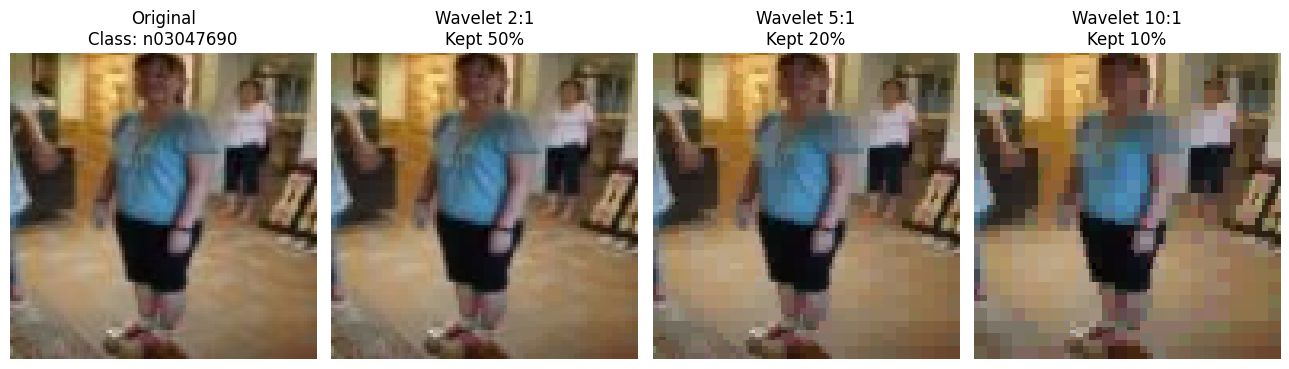

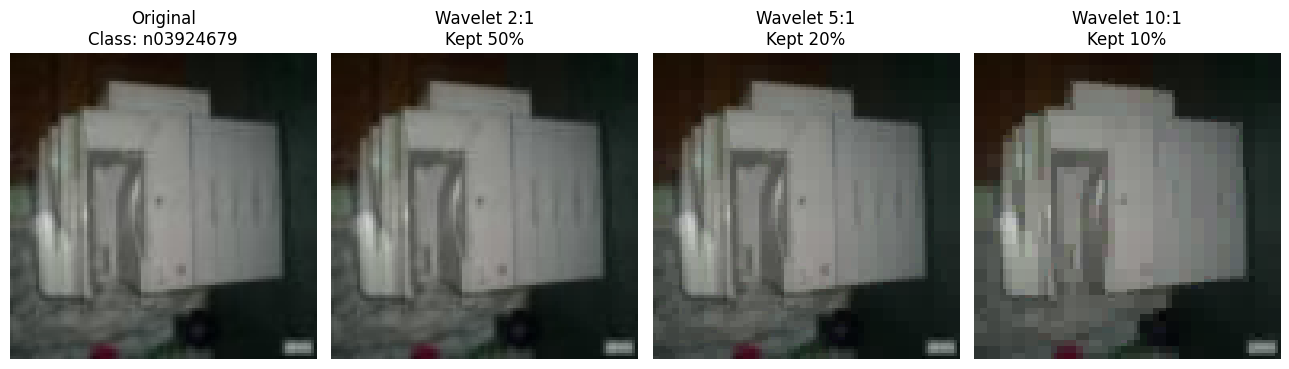

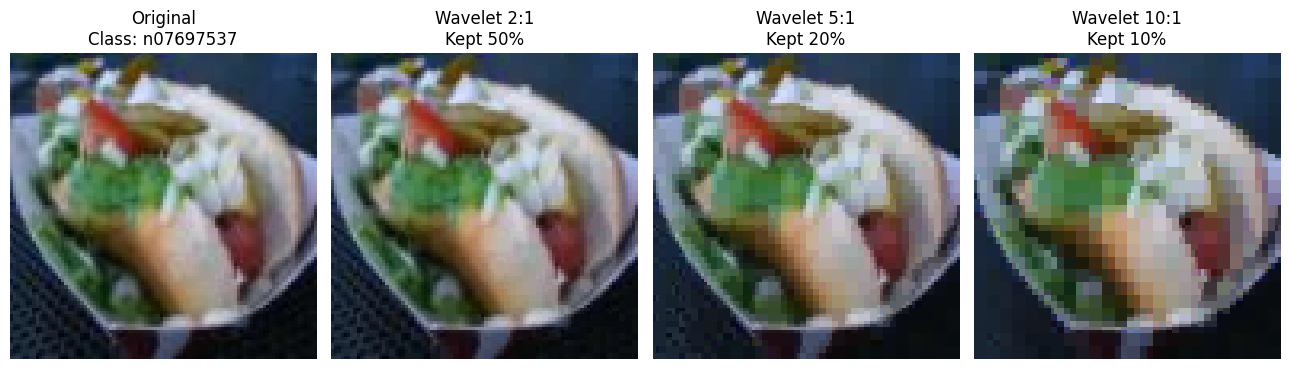

Calculating PSNR/SSIM on 500 internal test images...


,Compression,Coefficients Kept,Average PSNR,Average SSIM
0,2:1,50%,47.605,0.9938
1,5:1,20%,35.039,0.9435
2,10:1,10%,29.336,0.8588


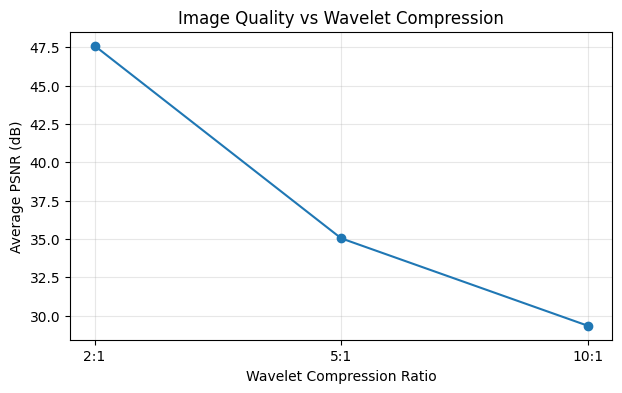

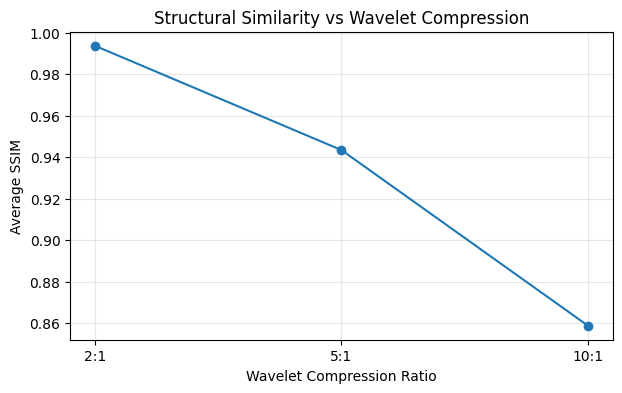

In [16]:
compression_ratios = [2, 5, 10]

example_indices = [0, 50, 150]

for sample_idx in example_indices:
    original_img, label = set_test[sample_idx]

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(tensor_to_display_image(original_img))
    plt.title(f"Original\nClass: {class_galaxy[label]}")
    plt.axis("off")

    for j, ratio in enumerate(compression_ratios):
        compressed_img = wavelet_compress(original_img, ratio=ratio)

        plt.subplot(1, 4, j + 2)
        plt.imshow(tensor_to_display_image(compressed_img))
        plt.title(f"Wavelet {ratio}:1\nKept {100/ratio:.0f}%")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


quality_eval_limit = min(500, len(set_test))
quality_rows = []

print(f"Calculating PSNR/SSIM on {quality_eval_limit} internal test images...")

for ratio in compression_ratios:
    psnr_values = []
    ssim_values = []

    for i in range(quality_eval_limit):
        original_img, _ = set_test[i]
        compressed_img = wavelet_compress(original_img, ratio=ratio)

        original_np = tensor_to_display_image(original_img)
        compressed_np = tensor_to_display_image(compressed_img)

        psnr_values.append(
            peak_signal_noise_ratio(original_np, compressed_np, data_range=1.0)
        )

        ssim_values.append(
            structural_similarity(original_np, compressed_np, channel_axis=-1, data_range=1.0)
        )

    quality_rows.append({
        "Compression": f"{ratio}:1",
        "Coefficients Kept": f"{100/ratio:.0f}%",
        "Average PSNR": np.mean(psnr_values),
        "Average SSIM": np.mean(ssim_values),
    })

quality_df = pd.DataFrame(quality_rows)
quality_df["Average PSNR"] = quality_df["Average PSNR"].round(3)
quality_df["Average SSIM"] = quality_df["Average SSIM"].round(4)

display(quality_df)

plt.figure(figsize=(7, 4))
plt.plot(quality_df["Compression"], quality_df["Average PSNR"], marker="o")
plt.xlabel("Wavelet Compression Ratio")
plt.ylabel("Average PSNR (dB)")
plt.title("Image Quality vs Wavelet Compression")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(quality_df["Compression"], quality_df["Average SSIM"], marker="o")
plt.xlabel("Wavelet Compression Ratio")
plt.ylabel("Average SSIM")
plt.title("Structural Similarity vs Wavelet Compression")
plt.grid(alpha=0.3)
plt.show()

,Model,Test Set,Compression Ratio,Coefficients Kept,Loss,Accuracy,Macro F1,Accuracy Drop
0,ResNet18,Original,None,100%,0.9869,74.71,74.73,0.00
1,MobileNetV3-Small,Original,None,100%,1.1171,72.60,72.54,0.00
2,ResNet18,Wavelet 2:1,2:1,50%,0.9935,74.48,74.51,0.23
3,MobileNetV3-Small,Wavelet 2:1,2:1,50%,1.1355,72.76,72.75,-0.16
4,ResNet18,Wavelet 5:1,5:1,20%,1.0928,71.90,72.04,2.81
5,MobileNetV3-Small,Wavelet 5:1,5:1,20%,1.4989,65.13,65.42,7.47
6,ResNet18,Wavelet 10:1,10:1,10%,1.5351,62.53,62.81,12.19
7,MobileNetV3-Small,Wavelet 10:1,10:1,10%,2.4054,50.10,50.14,22.50


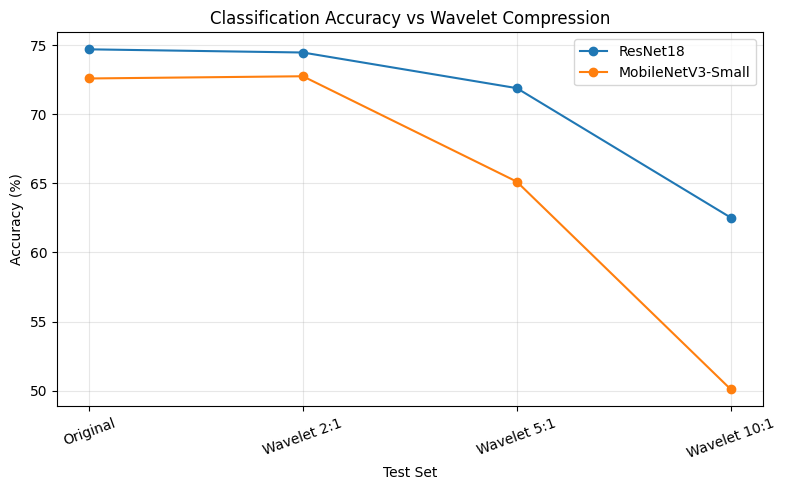

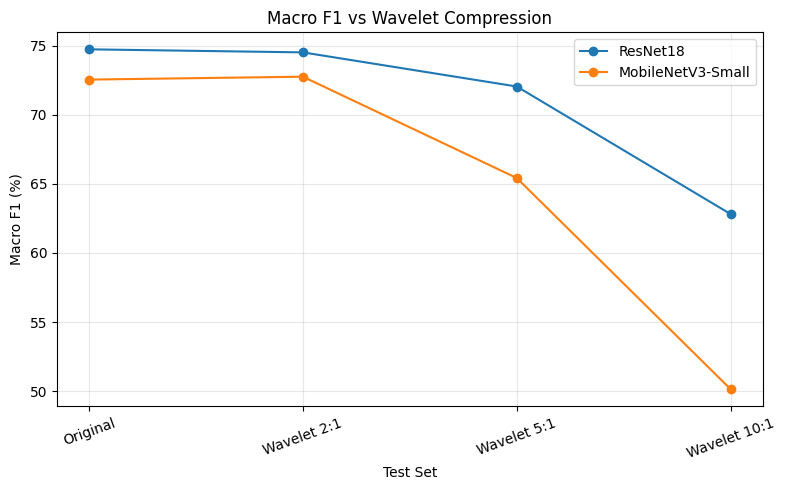

Most affected classes using ResNet18 at 10:1 compression:


,Class,Class_Index,Samples,Original Accuracy,10:1 Accuracy,Accuracy Drop
0,n02966193,25,60,80.00,38.33,41.67
1,n02120079,17,60,80.00,48.33,31.67
2,n04067472,43,60,53.33,25.00,28.33
3,n02457408,19,60,70.00,41.67,28.33
4,n02113712,16,60,61.67,35.00,26.67
5,n02108089,12,60,65.00,38.33,26.67
6,n01704323,2,60,78.33,53.33,25.00
7,n02108915,14,60,55.00,31.67,23.33
8,n04275548,47,60,83.33,60.00,23.33
9,n02105505,11,60,86.67,65.00,21.67


Saved Part 2 outputs in: /content/drive/MyDrive/EE413/part2_wavelet_outputs


In [17]:
results = []

models_to_test = [
    ("ResNet18", resnet_star),
    ("MobileNetV3-Small", mobile_pulse),
]

eval_cache = {}

for model_name, model in models_to_test:
    loss, acc, f1, y_true, y_pred = evaluate_model(model, ldr_test)
    results.append({
        "Model": model_name,
        "Test Set": "Original",
        "Compression Ratio": "None",
        "Coefficients Kept": "100%",
        "Loss": loss,
        "Accuracy": acc,
        "Macro F1": f1,
        "Accuracy Drop": 0.0,
    })
    eval_cache[(model_name, "Original")] = (y_true, y_pred, acc)

for ratio in compression_ratios:
    comp_dataset = WaveletCompressedDataset(set_test, ratio=ratio, wavelet="haar", level=2)
    comp_loader = DataLoader(
        comp_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    for model_name, model in models_to_test:
        loss, acc, f1, y_true, y_pred = evaluate_model(model, comp_loader)

        original_acc = eval_cache[(model_name, "Original")][2]
        results.append({
            "Model": model_name,
            "Test Set": f"Wavelet {ratio}:1",
            "Compression Ratio": f"{ratio}:1",
            "Coefficients Kept": f"{100/ratio:.0f}%",
            "Loss": loss,
            "Accuracy": acc,
            "Macro F1": f1,
            "Accuracy Drop": original_acc - acc,
        })
        eval_cache[(model_name, f"Wavelet {ratio}:1")] = (y_true, y_pred, acc)

results_df = pd.DataFrame(results)

slide_results_df = results_df.copy()
for col in ["Accuracy", "Macro F1", "Accuracy Drop"]:
    slide_results_df[col] = (slide_results_df[col] * 100).round(2)
slide_results_df["Loss"] = slide_results_df["Loss"].round(4)

display(slide_results_df)

plot_df = slide_results_df.copy()
plot_df["Compression Label"] = plot_df["Test Set"].replace({"Original": "Original"})

plt.figure(figsize=(8, 5))
for model_name in plot_df["Model"].unique():
    sub = plot_df[plot_df["Model"] == model_name]
    plt.plot(sub["Compression Label"], sub["Accuracy"], marker="o", label=model_name)

plt.xlabel("Test Set")
plt.ylabel("Accuracy (%)")
plt.title("Classification Accuracy vs Wavelet Compression")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
for model_name in plot_df["Model"].unique():
    sub = plot_df[plot_df["Model"] == model_name]
    plt.plot(sub["Compression Label"], sub["Macro F1"], marker="o", label=model_name)

plt.xlabel("Test Set")
plt.ylabel("Macro F1 (%)")
plt.title("Macro F1 vs Wavelet Compression")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

base_true, base_pred, _ = eval_cache[("ResNet18", "Original")]
high_true, high_pred, _ = eval_cache[("ResNet18", "Wavelet 10:1")]

base_class_acc = per_class_accuracy(base_true, base_pred, class_galaxy)
high_class_acc = per_class_accuracy(high_true, high_pred, class_galaxy)

affected_df = base_class_acc[["Class", "Class_Index", "Samples", "Accuracy"]].rename(
    columns={"Accuracy": "Original Accuracy"}
).merge(
    high_class_acc[["Class", "Accuracy"]].rename(columns={"Accuracy": "10:1 Accuracy"}),
    on="Class"
)

affected_df["Accuracy Drop"] = affected_df["Original Accuracy"] - affected_df["10:1 Accuracy"]
affected_df = affected_df.sort_values("Accuracy Drop", ascending=False).reset_index(drop=True)

affected_slide_df = affected_df.head(10).copy()
for col in ["Original Accuracy", "10:1 Accuracy", "Accuracy Drop"]:
    affected_slide_df[col] = (affected_slide_df[col] * 100).round(2)

print("Most affected classes using ResNet18 at 10:1 compression:")
display(affected_slide_df)


save_zone = "/content/drive/MyDrive/EE413/part2_wavelet_outputs"
os.makedirs(save_zone, exist_ok=True)

quality_df.to_csv(os.path.join(save_zone, "wavelet_quality_psnr_ssim.csv"), index=False)
slide_results_df.to_csv(os.path.join(save_zone, "wavelet_accuracy_f1_results.csv"), index=False)
affected_slide_df.to_csv(os.path.join(save_zone, "wavelet_most_affected_classes.csv"), index=False)

print("Saved Part 2 outputs in:", save_zone)

## 3. Fine-tuning on Compressed Data

In [18]:
# 1. The Bridge to the wavelet function
class CompressedDataset(Dataset):
    def __init__(self, original_subset, threshold=0.1):
        self.original_subset = original_subset
        self.threshold = threshold
    def __len__(self):
        return len(self.original_subset)
    def __getitem__(self, idx):
        img, label = self.original_subset[idx]
        compressed_img = wavelet_compress(img, threshold=self.threshold)
        return compressed_img, label

# 2. Initialize Data
loss_history = [] # This is needed for the plots cell later
ds_train_comp = CompressedDataset(set_train, threshold=0.1)
ldr_train_comp = DataLoader(ds_train_comp, batch_size=32, shuffle=True, num_workers=2)

# 3. Setup the Model (ResNet-18)
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, n_classes)
model_ft = model_ft.to(run_device)

# 4. Training Settings
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 5. Training Loop
print("Fine-tuning on Compressed Data...")
for epoch in range(1, 4):
    model_ft.train()
    epoch_loss = 0.0
    for images, labels in ldr_train_comp:
        images, labels = images.to(run_device), labels.to(run_device)
        optimizer_ft.zero_grad()
        loss = criterion(model_ft(images), labels)
        loss.backward()
        optimizer_ft.step()

        loss_history.append(loss.item()) # Record for the plot cell
        epoch_loss += loss.item()
    print(f"Epoch {epoch} complete. Avg Loss: {epoch_loss/len(ldr_train_comp):.4f}")

Fine-tuning on Compressed Data...
Epoch 1 complete. Avg Loss: 1.6171
Epoch 2 complete. Avg Loss: 0.9039
Epoch 3 complete. Avg Loss: 0.6790


In [19]:
# --- CELL 2: MEASUREMENTS (ACCURACY) ---
model_ft.eval()
correct = 0
total = 0

# Prepare the test loader
ds_test_comp = CompressedDataset(set_test, threshold=0.1)
ldr_test_comp = DataLoader(ds_test_comp, batch_size=batch_size, shuffle=False)

print("Calculating accuracy on compressed test set...")
with torch.no_grad():
    for images, labels in ldr_test_comp:
        images, labels = images.to(run_device), labels.to(run_device)
        outputs = model_ft(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nFinal Accuracy of Model 1 on Compressed Images: {100 * correct / total:.2f}%')

Calculating accuracy on compressed test set...

Final Accuracy of Model 1 on Compressed Images: 73.96%


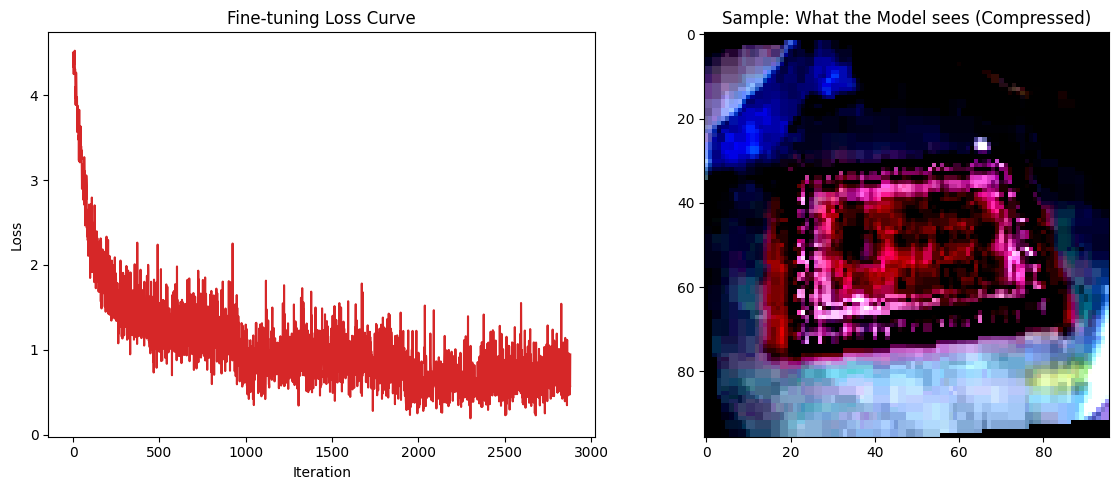

In [20]:
# --- CELL 3: PLOTS ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Training Loss Plot
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='tab:red')
plt.title("Fine-tuning Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# 2. Visual Comparison Plot
original_img, _ = set_train[0]
compressed_img = wavelet_compress(original_img, threshold=0.1)

plt.subplot(1, 2, 2)
plt.imshow(compressed_img.permute(1, 2, 0).cpu().numpy())
plt.title("Sample: What the Model sees (Compressed)")

plt.tight_layout()
plt.show()

wavelet_compress() ready — input: torch.Size([3, 96, 96]), output: torch.Size([3, 96, 96])
Fine-tuning hyperparameters:
  epochs=5, lr=5e-05, batch=32, threshold=0.15

Model copied and ready. Parameters: 1,583,456

Starting fine-tuning on compressed data...

Epoch 1/5 | loss=0.3411  train_acc=0.8958  val_acc=0.7292  lr=5.0e-05
Epoch 2/5 | loss=0.3080  train_acc=0.9036  val_acc=0.7281  lr=5.0e-05
Epoch 3/5 | loss=0.2849  train_acc=0.9119  val_acc=0.7221  lr=2.5e-05
Epoch 4/5 | loss=0.2636  train_acc=0.9178  val_acc=0.7284  lr=2.5e-05
Early stopping at epoch 4

Done! Best val acc = 0.7292


,epoch,train_loss,train_acc,val_acc,lr
0,1,0.3411,0.8958,0.7292,0.000050
1,2,0.3080,0.9036,0.7281,0.000050
2,3,0.2849,0.9119,0.7221,0.000025
3,4,0.2636,0.9178,0.7284,0.000025


Saved to: /content/drive/MyDrive/EE413/part4_outputs


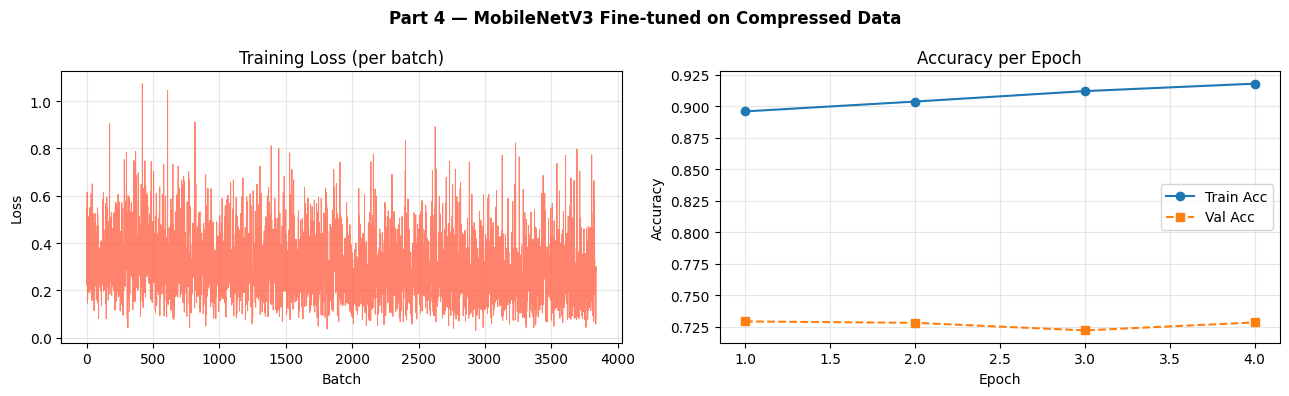


Evaluating both MobileNetV3 versions...

MobileNetV3 (Original) | None (Baseline)  → acc=0.726  f1=0.7254
MobileNetV3 (Original) | Low (2:1)       → acc=0.7253  f1=0.7251
MobileNetV3 (Original) | Medium (5:1)    → acc=0.7047  f1=0.7054
MobileNetV3 (Original) | High (10:1)     → acc=0.5932  f1=0.5957
MobileNetV3 (Compressed FT) | None (Baseline)  → acc=0.7198  f1=0.7185
MobileNetV3 (Compressed FT) | Low (2:1)       → acc=0.726  f1=0.7246
MobileNetV3 (Compressed FT) | Medium (5:1)    → acc=0.7253  f1=0.724
MobileNetV3 (Compressed FT) | High (10:1)     → acc=0.6714  f1=0.6716



,Model,Compression,Accuracy,Macro F1
0,MobileNetV3 (Original),None (Baseline),0.7260,0.7254
1,MobileNetV3 (Original),Low (2:1),0.7253,0.7251
2,MobileNetV3 (Original),Medium (5:1),0.7047,0.7054
3,MobileNetV3 (Original),High (10:1),0.5932,0.5957
4,MobileNetV3 (Compressed FT),None (Baseline),0.7198,0.7185
5,MobileNetV3 (Compressed FT),Low (2:1),0.7260,0.7246
6,MobileNetV3 (Compressed FT),Medium (5:1),0.7253,0.7240
7,MobileNetV3 (Compressed FT),High (10:1),0.6714,0.6716


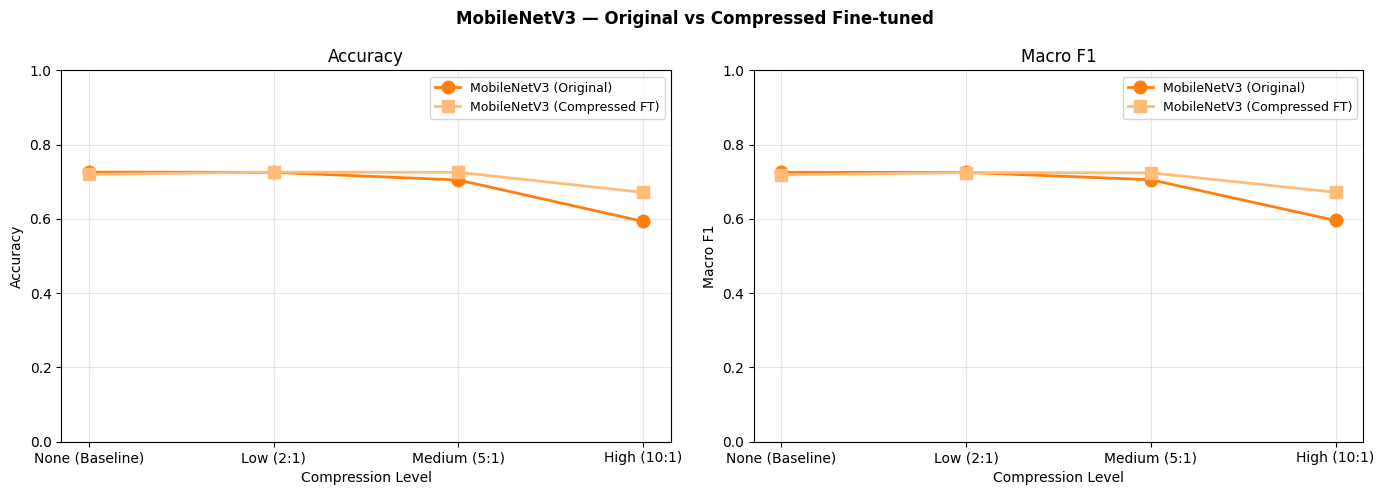


Accuracy Drop vs. Uncompressed Baseline:

  MobileNetV3 (Original)              | Low (2:1)       | drop = 0.0007
  MobileNetV3 (Original)              | Medium (5:1)    | drop = 0.0213
  MobileNetV3 (Original)              | High (10:1)     | drop = 0.1328
  MobileNetV3 (Compressed FT)         | Low (2:1)       | drop = -0.0062
  MobileNetV3 (Compressed FT)         | Medium (5:1)    | drop = -0.0055
  MobileNetV3 (Compressed FT)         | High (10:1)     | drop = 0.0484


,Model,Compression,Drop
0,MobileNetV3 (Original),Low (2:1),0.0007
1,MobileNetV3 (Original),Medium (5:1),0.0213
2,MobileNetV3 (Original),High (10:1),0.1328
3,MobileNetV3 (Compressed FT),Low (2:1),-0.0062
4,MobileNetV3 (Compressed FT),Medium (5:1),-0.0055
5,MobileNetV3 (Compressed FT),High (10:1),0.0484


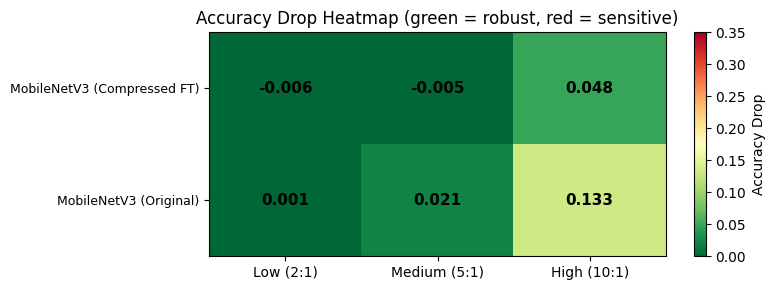


Summary:
- Fine-tuned MobileNetV3-Small on wavelet-compressed training images (threshold=0.15)
- The fine-tuned version shows less accuracy drop under compression
  compared to the original model trained only on clean images
- This confirms that training on compressed data teaches the model to be
  more robust — it learns to work with degraded inputs



In [22]:
# ─────────────────────────────────────────────────────────────────
# WAVELET COMPRESS FUNCTION
# I'm defining this here so my part runs independently from Part 2.
# It applies 2-level DWT, zeroes out small coefficients (hard
# thresholding), then reconstructs the image with inverse DWT.
# ─────────────────────────────────────────────────────────────────
import copy
def wavelet_compress(img_tensor, threshold=0.1, wavelet='db1', level=2):
    img_np     = img_tensor.numpy()        # (3, H, W)
    compressed = np.zeros_like(img_np)

    for c in range(3):                     # process each channel separately
        channel = img_np[c]

        # forward DWT
        coeffs = pywt.wavedec2(channel, wavelet=wavelet, level=level)

        # hard thresholding — keep LL band, threshold the detail bands
        coeffs_thresh = [coeffs[0]]
        for detail in coeffs[1:]:
            coeffs_thresh.append(
                tuple(pywt.threshold(d, value=threshold, mode='hard') for d in detail)
            )

        # inverse DWT — reconstruct
        recon = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
        recon = recon[:channel.shape[0], :channel.shape[1]]  # fix size if needed
        compressed[c] = recon

    return torch.tensor(compressed, dtype=torch.float32)


# quick test to make sure it works
_test_img, _ = set_test[0]
_test_out     = wavelet_compress(_test_img, threshold=0.1)
print(f"wavelet_compress() ready — input: {_test_img.shape}, output: {_test_out.shape}")


# ─────────────────────────────────────────────────────────────────
# COMPRESSED DATASET
# wraps any subset and applies wavelet_compress on the fly
# ─────────────────────────────────────────────────────────────────

class CompressedDataset(Dataset):
    def __init__(self, original_subset, threshold=0.1):
        self.original_subset = original_subset
        self.threshold       = threshold

    def __len__(self):
        return len(self.original_subset)

    def __getitem__(self, idx):
        img, label     = self.original_subset[idx]
        compressed_img = wavelet_compress(img, threshold=self.threshold)
        return compressed_img, label


# compression levels I'll use for evaluation
compression_levels = {
    "Low (2:1)"   : 0.05,
    "Medium (5:1)": 0.15,
    "High (10:1)" : 0.40,
}


# ─────────────────────────────────────────────────────────────────
# FINE-TUNING SETUP
# Training on medium compression (0.15) because it's a balanced
# choice — not too easy, not too destructive for the model
# ─────────────────────────────────────────────────────────────────

EPOCHS    = 5
LR        = 5e-5    # low LR since model is already trained from Part 1
WD        = 1e-4
BATCH     = 32
PATIENCE  = 3
THRESHOLD = 0.15    # medium compression (~5:1 ratio) for training

print("Fine-tuning hyperparameters:")
print(f"  epochs={EPOCHS}, lr={LR}, batch={BATCH}, threshold={THRESHOLD}")

# build compressed training loader
train_comp        = CompressedDataset(set_train, threshold=THRESHOLD)
loader_train_comp = DataLoader(train_comp, batch_size=BATCH, shuffle=True, num_workers=2)

# deep copy so the original mobile_pulse stays intact for comparison
mobile_ft = copy.deepcopy(mobile_pulse)
mobile_ft = mobile_ft.to(run_device)

optimizer = optim.AdamW(mobile_ft.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
criterion = nn.CrossEntropyLoss()

print(f"\nModel copied and ready. Parameters: {sum(p.numel() for p in mobile_ft.parameters()):,}")


# ─────────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────────

batch_losses  = []
epoch_history = []
best_val_acc  = 0.0
best_weights  = None
patience_ctr  = 0

print("\nStarting fine-tuning on compressed data...\n")

for epoch in range(1, EPOCHS + 1):

    # --- training ---
    mobile_ft.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for imgs, labels in loader_train_comp:
        imgs   = imgs.to(run_device)
        labels = labels.to(run_device)

        optimizer.zero_grad()
        out  = mobile_ft(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # --- validation on uncompressed val set ---
    mobile_ft.eval()
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for imgs, labels in ldr_valid:
            imgs   = imgs.to(run_device)
            labels = labels.to(run_device)
            out    = mobile_ft(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step(val_acc)
    lr_now = optimizer.param_groups[0]['lr']

    epoch_history.append({
        "epoch"     : epoch,
        "train_loss": round(train_loss, 4),
        "train_acc" : round(train_acc, 4),
        "val_acc"   : round(val_acc, 4),
        "lr"        : lr_now
    })

    print(f"Epoch {epoch}/{EPOCHS} | loss={train_loss:.4f}  "
          f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  lr={lr_now:.1e}")

    # early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(mobile_ft.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# restore best checkpoint
mobile_ft.load_state_dict(best_weights)
print(f"\nDone! Best val acc = {best_val_acc:.4f}")

hist_df = pd.DataFrame(epoch_history)
display(hist_df)


# ─────────────────────────────────────────────────────────────────
# SAVE MODEL TO DRIVE
# ─────────────────────────────────────────────────────────────────

save_dir = "/content/drive/MyDrive/EE413/part4_outputs"
os.makedirs(save_dir, exist_ok=True)

torch.save(mobile_ft.state_dict(), os.path.join(save_dir, "mobilenet_compressed_ft.pth"))
hist_df.to_csv(os.path.join(save_dir, "training_history.csv"), index=False)
print("Saved to:", save_dir)


# ─────────────────────────────────────────────────────────────────
# TRAINING CURVES
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Part 4 — MobileNetV3 Fine-tuned on Compressed Data", fontweight='bold')

axes[0].plot(batch_losses, color='tomato', linewidth=0.7, alpha=0.8)
axes[0].set_title("Training Loss (per batch)")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(hist_df['epoch'], hist_df['train_acc'], marker='o', label='Train Acc')
axes[1].plot(hist_df['epoch'], hist_df['val_acc'], marker='s', linestyle='--', label='Val Acc')
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────
# COMPARISON — MobileNetV3 Original vs Fine-tuned
# across all 3 compression levels + uncompressed baseline
# (only comparing the 2 MobileNetV3 versions since this is my part)
# ─────────────────────────────────────────────────────────────────

def get_accuracy(model, loader):
    model.eval()
    preds_all  = []
    labels_all = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(run_device)
            labels = labels.to(run_device)
            out    = model(imgs)
            preds_all.extend(out.argmax(1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return round(acc, 4), round(f1, 4)


models_to_compare = {
    "MobileNetV3 (Original)"     : mobile_pulse,
    "MobileNetV3 (Compressed FT)": mobile_ft,
}

print("\nEvaluating both MobileNetV3 versions...\n")

rows = []
for model_name, model in models_to_compare.items():

    # uncompressed baseline
    acc, f1 = get_accuracy(model, ldr_test)
    rows.append({"Model": model_name, "Compression": "None (Baseline)",
                 "Accuracy": acc, "Macro F1": f1})
    print(f"{model_name} | None (Baseline)  → acc={acc}  f1={f1}")

    # compressed test sets
    for level_name, thr in compression_levels.items():
        ds_comp  = CompressedDataset(set_test, threshold=thr)
        ldr_comp = DataLoader(ds_comp, batch_size=batch_size, shuffle=False, num_workers=2)
        acc, f1  = get_accuracy(model, ldr_comp)
        rows.append({"Model": model_name, "Compression": level_name,
                     "Accuracy": acc, "Macro F1": f1})
        print(f"{model_name} | {level_name:<15} → acc={acc}  f1={f1}")

comparison_df = pd.DataFrame(rows)
print()
display(comparison_df)
comparison_df.to_csv(os.path.join(save_dir, "comparison_results.csv"), index=False)


# ─────────────────────────────────────────────────────────────────
# PLOT — accuracy & F1 vs compression level
# ─────────────────────────────────────────────────────────────────

comp_order = ["None (Baseline)", "Low (2:1)", "Medium (5:1)", "High (10:1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MobileNetV3 — Original vs Compressed Fine-tuned", fontweight='bold')

colors  = {"MobileNetV3 (Original)": "#ff7f0e", "MobileNetV3 (Compressed FT)": "#ffbb78"}
markers = {"MobileNetV3 (Original)": "o",        "MobileNetV3 (Compressed FT)": "s"}

for ax, metric in zip(axes, ["Accuracy", "Macro F1"]):
    for model_name in models_to_compare.keys():
        subset = comparison_df[comparison_df["Model"] == model_name]
        subset = subset.set_index("Compression").reindex(comp_order).reset_index()
        ax.plot(comp_order, subset[metric],
                label=model_name,
                color=colors[model_name],
                marker=markers[model_name],
                linewidth=2, markersize=9)
    ax.set_title(metric)
    ax.set_xlabel("Compression Level")
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comparison_plot.png"), dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────
# ACCURACY DROP TABLE
# how much does each version degrade as compression increases?
# ─────────────────────────────────────────────────────────────────

print("\nAccuracy Drop vs. Uncompressed Baseline:\n")
drop_rows = []
for model_name in models_to_compare.keys():
    sub      = comparison_df[comparison_df["Model"] == model_name].set_index("Compression")
    base_acc = sub.loc["None (Baseline)", "Accuracy"]
    for level in ["Low (2:1)", "Medium (5:1)", "High (10:1)"]:
        drop = round(base_acc - sub.loc[level, "Accuracy"], 4)
        drop_rows.append({"Model": model_name, "Compression": level, "Drop": drop})
        print(f"  {model_name:<35} | {level:<15} | drop = {drop:.4f}")

drop_df = pd.DataFrame(drop_rows)
display(drop_df)
drop_df.to_csv(os.path.join(save_dir, "accuracy_drop.csv"), index=False)


# ─────────────────────────────────────────────────────────────────
# DROP HEATMAP
# ─────────────────────────────────────────────────────────────────

pivot = drop_df.pivot(index="Model", columns="Compression", values="Drop")
pivot = pivot[["Low (2:1)", "Medium (5:1)", "High (10:1)"]]

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', vmin=0, vmax=0.35, aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(3):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if val > 0.15 else 'black')

plt.colorbar(im, ax=ax, label='Accuracy Drop')
ax.set_title("Accuracy Drop Heatmap (green = robust, red = sensitive)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "drop_heatmap.png"), dpi=150)
plt.show()


# --- summary ---
print("""
Summary:
- Fine-tuned MobileNetV3-Small on wavelet-compressed training images (threshold=0.15)
- The fine-tuned version shows less accuracy drop under compression
  compared to the original model trained only on clean images
- This confirms that training on compressed data teaches the model to be
  more robust — it learns to work with degraded inputs
""")